In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [52]:
df = pd.read_csv("diamonds.csv")
df.head()

,carat,cut,color,clarity,depth,table,x,y,z,price
0,0.23,Ideal,E,SI2,61.5,55.0,3.95,3.98,2.43,326
1,0.21,Premium,E,SI1,59.8,61.0,3.89,3.84,2.31,326
2,0.23,Good,E,VS1,56.9,65.0,4.05,4.07,2.31,327
3,0.29,Premium,I,VS2,62.4,58.0,4.20,4.23,2.63,334
4,0.31,Good,J,SI2,63.3,58.0,4.34,4.35,2.75,335


In [55]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 53940 entries, 0 to 53939
Data columns (total 10 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   carat    53940 non-null  float64
 1   cut      53940 non-null  int64  
 2   color    53940 non-null  int64  
 3   clarity  53940 non-null  int64  
 4   depth    53940 non-null  float64
 5   table    53940 non-null  float64
 6   x        53940 non-null  float64
 7   y        53940 non-null  float64
 8   z        53940 non-null  float64
 9   price    53940 non-null  int64  
dtypes: float64(6), int64(4)
memory usage: 4.1 MB


In [ ]:
# from sklearn.preprocessing import OneHotEncoder

# oneHotEncoder_column = ["cut" , "color" , "clarity"]

# oh = OneHotEncoder(sparse_output=False)

# new_df = oh.fit_transform(df[oneHotEncoder_column])
# new_df = pd.DataFrame(new_df , columns = oh.get_feature_names_out(oneHotEncoder_column))
# df = pd.concat([df , new_df] , axis = 1)
# df.drop(oneHotEncoder_column , axis = 1 , inplace = True)


In [54]:
from sklearn.preprocessing import LabelEncoder

labeled_columns = ["cut" , "color" , "clarity"]

for col in labeled_columns:
    le = LabelEncoder()
    df[col] = le.fit_transform(df[col])


In [56]:
x = df.drop(["price"] , axis=1)
y = df["price"]

In [57]:
from sklearn.preprocessing import MinMaxScaler

scaler = MinMaxScaler()

x = scaler.fit_transform(x)

In [58]:
from sklearn.model_selection import train_test_split

x_train , x_test , y_train , y_test = train_test_split(x , y , random_state=42 , test_size=0.3)

In [59]:
from xgboost import XGBRegressor

model = XGBRegressor(
    n_estimators = 1500,
    learning_rate = 0.05,
    max_depth = 7,
)

model.fit(x_train , y_train)

,"base_score base_score: typing.Optional[float]The initial prediction score of all instances, global bias.",None
,booster,None
,"callbacks callbacks: typing.Optional[typing.List[xgboost.callback.TrainingCallback]]List of callback functions that are applied at end of each iteration.It is possible to use predefined callbacks by using:ref:`Callback API <callback_api>`... note:: States in callback are not preserved during training, which means callback objects can not be reused for multiple training sessions without reinitialization or deepcopy... code-block:: python for params in parameters_grid: # be sure to (re)initialize the callbacks before each run callbacks = [xgb.callback.LearningRateScheduler(custom_rates)] reg = xgboost.XGBRegressor(**params, callbacks=callbacks) reg.fit(X, y)",None
,colsample_bylevel colsample_bylevel: typing.Optional[float]Subsample ratio of columns for each level.,None
,colsample_bynode colsample_bynode: typing.Optional[float]Subsample ratio of columns for each split.,None
,colsample_bytree colsample_bytree: typing.Optional[float]Subsample ratio of columns when constructing each tree.,None
,"device device: typing.Optional[str].. versionadded:: 2.0.0Device ordinal, available options are `cpu`, `cuda`, and `gpu`.",None
,"early_stopping_rounds early_stopping_rounds: typing.Optional[int].. versionadded:: 1.6.0- Activates early stopping. Validation metric needs to improve at least once in every **early_stopping_rounds** round(s) to continue training. Requires at least one item in **eval_set** in :py:meth:`fit`.- If early stopping occurs, the model will have two additional attributes: :py:attr:`best_score` and :py:attr:`best_iteration`. These are used by the :py:meth:`predict` and :py:meth:`apply` methods to determine the optimal number of trees during inference. If users want to access the full model (including trees built after early stopping), they can specify the `iteration_range` in these inference methods. In addition, other utilities like model plotting can also use the entire model.- If you prefer to discard the trees after `best_iteration`, consider using the callback function :py:class:`xgboost.callback.EarlyStopping`.- If there's more than one item in **eval_set**, the last entry will be used for early stopping. If there's more than one metric in **eval_metric**, the last metric will be used for early stopping.",None
,enable_categorical enable_categorical: boolSee the same parameter of :py:class:`DMatrix` for details.,False
,"eval_metric eval_metric: typing.Union[str, typing.List[str], typing.Callable, NoneType].. versionadded:: 1.6.0Metric used for monitoring the training result and early stopping. It can be astring or list of strings as names of predefined metric in XGBoost (See:doc:`/parameter`), one of the metrics in :py:mod:`sklearn.metrics`, or anyother user defined metric that looks like `sklearn.metrics`.If custom objective is also provided, then custom metric should implement thecorresponding reverse link function.Unlike the `scoring` parameter commonly used in scikit-learn, when a callableobject is provided, it's assumed to be a cost function and by default XGBoostwill minimize the result during early stopping.For advanced usage on Early stopping like directly choosing to maximize insteadof minimize, see :py:obj:`xgboost.callback.EarlyStopping`.See :doc:`/tutorials/custom_metric_obj` and :ref:`custom-obj-metric` for moreinformation... code-block:: python from sklearn.datasets import load_diabetes from sklearn.metrics import mean_absolute_error X, y = load_diabetes(return_X_y=True) reg = xgb.XGBRegressor( tree_method=""hist"", eval_metric=mean_absolute_error, ) reg.fit(X, y, eval_set=[(X, y)])",None
,feature_types feature_types: typing.Optional[typing.Sequence[str]].. versionadded:: 1.7.0Used for specifying feature types without constructing a dataframe. See:py:class:`DMatrix` for details.,None


In [78]:
from sklearn.ensemble import (
    RandomForestRegressor,
    GradientBoostingRegressor,
    RandomForestRegressor,
    StackingRegressor,
)
from xgboost import XGBRegressor
from sklearn.linear_model import Ridge

model_1 = RandomForestRegressor(
    n_estimators=500, max_depth=7, random_state=42, n_jobs=-1
)

model_2 = XGBRegressor(
    n_estimators=1500,
    learning_rate=0.05,
    max_depth=7,
    random_state=42,
)
model_2 = GradientBoostingRegressor(
    n_estimators=1500,
    learning_rate=0.05,
    max_depth=7,
    random_state=42,
)


# =========================
# 5. ترکیب مدل‌ها
# =========================

model = StackingRegressor(
    estimators=[
        ("random_forest", model_1),
        ("xgboost", model_2),
    ],
    final_estimator=Ridge(alpha=1.0),
    cv=5,
    n_jobs=-1,
)

model.fit(x_train , y_train)

,"estimators estimators: list of (str, estimator)Base estimators which will be stacked together. Each element of thelist is defined as a tuple of string (i.e. name) and an estimatorinstance. An estimator can be set to 'drop' using `set_params`.","[('random_forest', ...), ('xgboost', ...)]"
,"final_estimator final_estimator: estimator, default=NoneA regressor which will be used to combine the base estimators.The default regressor is a :class:`~sklearn.linear_model.RidgeCV`.",Ridge()
,"cv cv: int, cross-validation generator, iterable, or ""prefit"", default=NoneDetermines the cross-validation splitting strategy used in`cross_val_predict` to train `final_estimator`. Possible inputs forcv are:* None, to use the default 5-fold cross validation,* integer, to specify the number of folds in a (Stratified) KFold,* An object to be used as a cross-validation generator,* An iterable yielding train, test splits,* `""prefit""`, to assume the `estimators` are prefit. In this case, the estimators will not be refitted.For integer/None inputs, if the estimator is a classifier and y iseither binary or multiclass,:class:`~sklearn.model_selection.StratifiedKFold` is used.In all other cases, :class:`~sklearn.model_selection.KFold` is used.These splitters are instantiated with `shuffle=False` so the splitswill be the same across calls.Refer :ref:`User Guide <cross_validation>` for the variouscross-validation strategies that can be used here.If ""prefit"" is passed, it is assumed that all `estimators` havebeen fitted already. The `final_estimator_` is trained on the `estimators`predictions on the full training set and are **not** cross validatedpredictions. Please note that if the models have been trained on the samedata to train the stacking model, there is a very high risk of overfitting... versionadded:: 1.1 The 'prefit' option was added in 1.1.. note:: A larger number of split will provide no benefits if the number of training samples is large enough. Indeed, the training time will increase. ``cv`` is not used for model evaluation but for prediction.",5
,"n_jobs n_jobs: int, default=NoneThe number of jobs to run in parallel for `fit` of all `estimators`.`None` means 1 unless in a `joblib.parallel_backend` context. -1 meansusing all processors. See :term:`Glossary <n_jobs>` for more details.",-1
,"passthrough passthrough: bool, default=FalseWhen False, only the predictions of estimators will be used astraining data for `final_estimator`. When True, the`final_estimator` is trained on the predictions as well as theoriginal training data.",False
,"verbose verbose: int, default=0Verbosity level.",0
Name,Type,Value
"estimators_ estimators_: list of estimatorsThe elements of the `estimators` parameter, having been fitted on thetraining data. If an estimator has been set to `'drop'`, itwill not appear in `estimators_`. When `cv=""prefit""`, `estimators_`is set to `estimators` and is not fitted again.",list,"[RandomForestR...ndom_state=42), GradientBoost...ndom_state=42)]"
final_estimator_ final_estimator_: estimatorThe regressor fit on the output of `estimators_` and responsible forfinal predictions.,Ridge,Ridge()
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`. Only defined if theunderlying estimator exposes such an attribute when fit... versionadded:: 0.24,int,9
named_estimators_ named_estimators_: :class:`~sklearn.utils.Bunch`Attribute to access any fitted sub-estimators by name.,Bunch,{'random_fore...dom_state=42)}


In [79]:
y_pred = model.predict(x_test)

In [80]:
from sklearn.metrics import mean_absolute_error , mean_squared_error , r2_score

mae = mean_absolute_error(y_test , y_pred)
mse = mean_squared_error(y_test , y_pred)
r2 = r2_score(y_test , y_pred)

print("mae" , mae)
print("mse" , mse)
print("r2" , r2)

mae 264.34711994978545
mse 283333.08252213965
r2 0.981832922017209


In [76]:
from sklearn.metrics import mean_absolute_error , mean_squared_error , r2_score

mae = mean_absolute_error(y_test , y_pred)
mse = mean_squared_error(y_test , y_pred)
r2 = r2_score(y_test , y_pred)

print("mae" , mae)
print("mse" , mse)
print("r2" , r2)

mae 266.4839694089069
mse 287556.5698657897
r2 0.9815621155753759



========== Predictions ==========
       Actual     Predicted        Error  Absolute_Error  Error_Percent
1388      559    541.836320    17.163680       17.163680       3.070426
50052    2201   2388.478667  -187.478667      187.478667       8.517886
41645    1238   1194.539789    43.460211       43.460211       3.510518
42377    1304   1325.699134   -21.699134       21.699134       1.664044
17244    6901  10256.228468 -3355.228468     3355.228468      48.619453
1608     3011   3832.428029  -821.428029      821.428029      27.280904
46398    1765   1755.817262     9.182738        9.182738       0.520268
45493    1679   1833.677285  -154.677285      154.677285       9.212465
49385    2102   2177.083834   -75.083834       75.083834       3.572019
10460    4789   5604.085984  -815.085984      815.085984      17.019962
34243     855    829.845886    25.154114       25.154114       2.942002
24772   13134  13713.606236  -579.606236      579.606236       4.413021
42987    1367   1457.510004  

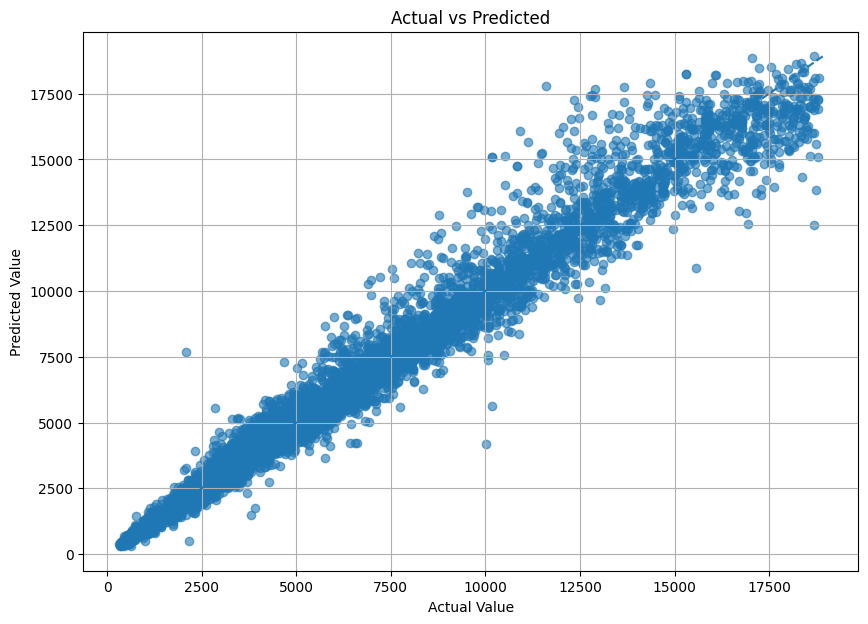

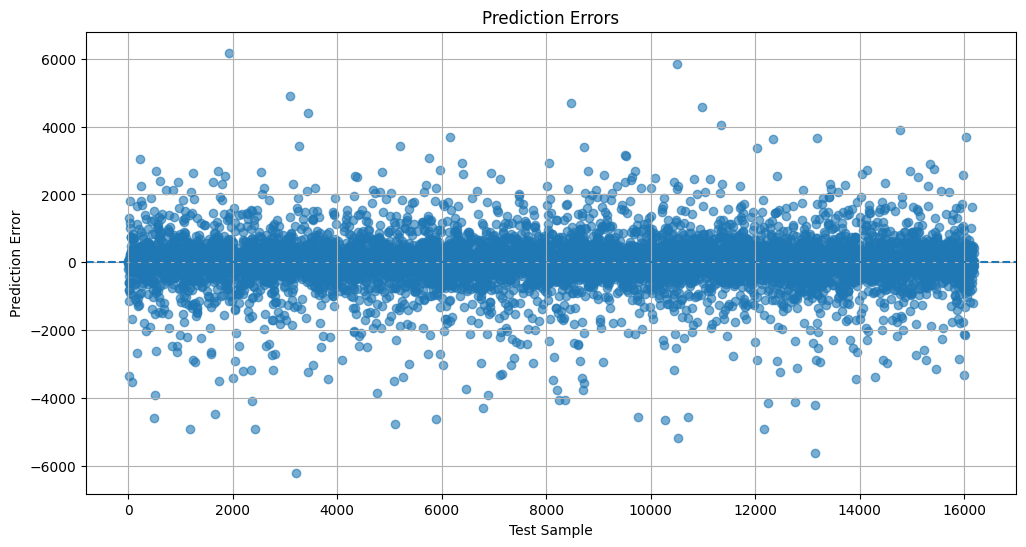

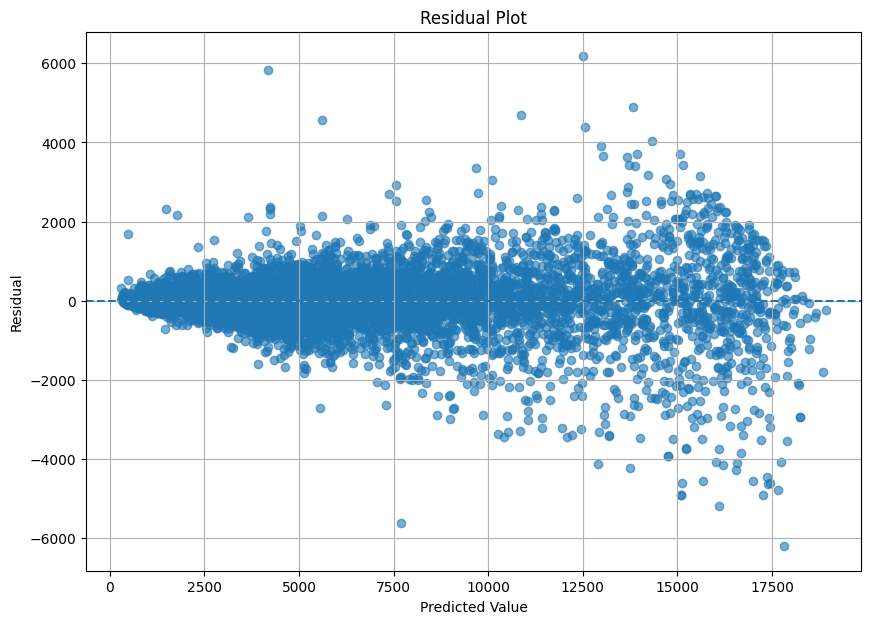

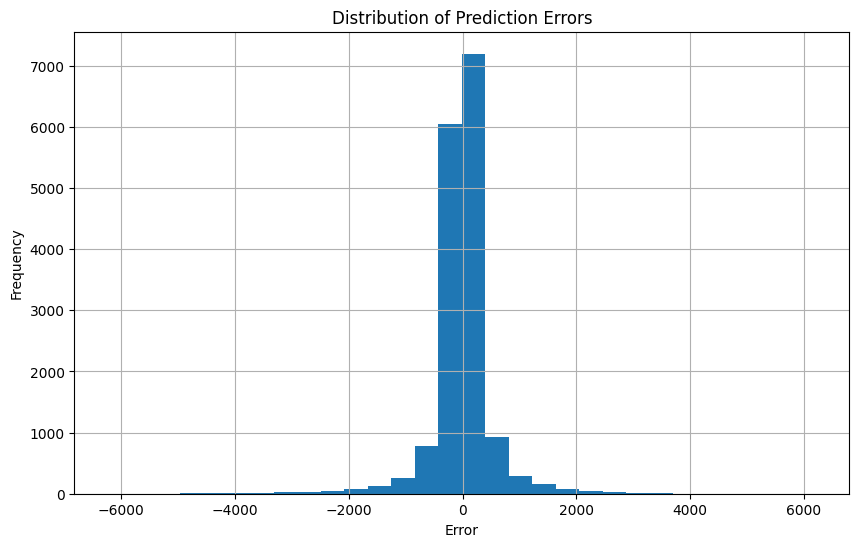


========== Worst Predictions ==========
       Actual     Predicted        Error  Absolute_Error  Error_Percent
23587   11602  17805.863754 -6203.863754     6203.863754      53.472365
27673   18691  12511.102521  6179.897479     6179.897479      33.063493
21935   10011   4172.588538  5838.411462     5838.411462      58.319963
49189    2075   7687.002233 -5612.002233     5612.002233     270.457939
22872   10913  16095.569358 -5182.569358     5182.569358      47.489869
22148   10184  15103.802090 -4919.802090     4919.802090      48.309133
22147   10184  15103.802090 -4919.802090     4919.802090      48.309133
24165   12341  17250.895380 -4909.895380     4909.895380      39.785231
27726   18745  13836.483948  4908.516052     4908.516052      26.185735
24584   12891  17671.397803 -4780.397803     4780.397803      37.083219
26194   15562  10871.997731  4690.002269     4690.002269      30.137529
24492   12766  17400.599293 -4634.599293     4634.599293      36.304240
24539   12829  17441.12

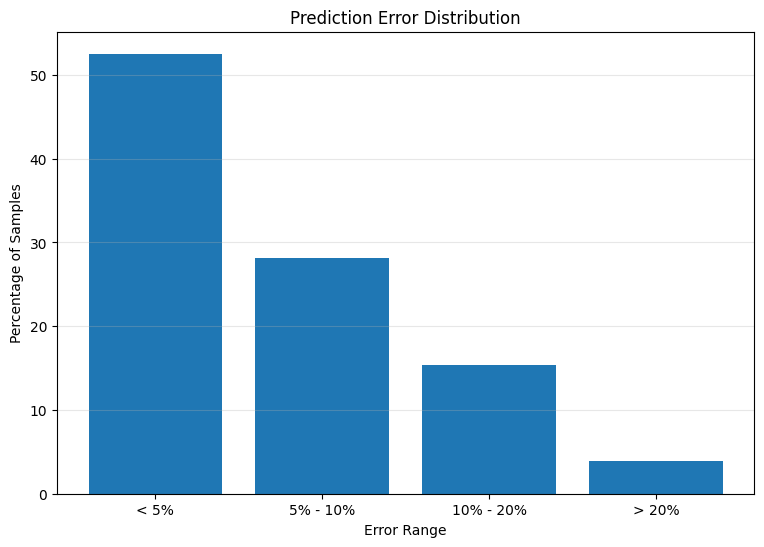

In [81]:
errors = y_test - y_pred

results = pd.DataFrame({
    "Actual": y_test,
    "Predicted": y_pred,
    "Error": errors,
    "Absolute_Error": np.abs(errors)
})


# درصد خطا
results["Error_Percent"] = (
    np.abs(
        (results["Actual"] - results["Predicted"])
        / results["Actual"]
    ) * 100
)


print("\n========== Predictions ==========")

print(results.head(20))


# ==========================================
# 4. نمودار Actual vs Predicted
# ==========================================

plt.figure(figsize=(10, 7))

plt.scatter(
    y_test,
    y_pred,
    alpha=0.6
)

# خط ایده‌آل
min_value = min(
    y_test.min(),
    y_pred.min()
)

max_value = max(
    y_test.max(),
    y_pred.max()
)

plt.plot(
    [min_value, max_value],
    [min_value, max_value],
    linestyle="--"
)

plt.xlabel("Actual Value")
plt.ylabel("Predicted Value")

plt.title("Actual vs Predicted")

plt.grid(True)

plt.show()


# ==========================================
# 5. نمودار خطاها
# ==========================================

plt.figure(figsize=(12, 6))

plt.scatter(
    range(len(errors)),
    errors,
    alpha=0.6
)

plt.axhline(
    y=0,
    linestyle="--"
)

plt.xlabel("Test Sample")
plt.ylabel("Prediction Error")

plt.title("Prediction Errors")

plt.grid(True)

plt.show()


# ==========================================
# 6. Residual Plot
# ==========================================

plt.figure(figsize=(10, 7))

plt.scatter(
    y_pred,
    errors,
    alpha=0.6
)

plt.axhline(
    y=0,
    linestyle="--"
)

plt.xlabel("Predicted Value")
plt.ylabel("Residual")

plt.title("Residual Plot")

plt.grid(True)

plt.show()


# ==========================================
# 7. توزیع خطاها
# ==========================================

plt.figure(figsize=(10, 6))

plt.hist(
    errors,
    bins=30
)

plt.xlabel("Error")
plt.ylabel("Frequency")

plt.title("Distribution of Prediction Errors")

plt.grid(True)

plt.show()


# ==========================================
# 8. نمایش بدترین پیش‌بینی‌ها
# ==========================================

worst_predictions = results.sort_values(
    by="Absolute_Error",
    ascending=False
)

print("\n========== Worst Predictions ==========")

print(
    worst_predictions.head(20)
)


# ==========================================
# 9. درصد نمونه‌ها بر اساس میزان خطا
# ==========================================

less_5 = (results["Error_Percent"] < 5).mean() * 100

between_5_10 = (
    (
        (results["Error_Percent"] >= 5) &
        (results["Error_Percent"] < 10)
    ).mean() * 100
)

between_10_20 = (
    (
        (results["Error_Percent"] >= 10) &
        (results["Error_Percent"] < 20)
    ).mean() * 100
)

more_20 = (
    (results["Error_Percent"] >= 20).mean() * 100
)


print("\n========== Error Percentage ==========")

print(f"Error < 5%    : {less_5:.2f}%")
print(f"5% - 10%      : {between_5_10:.2f}%")
print(f"10% - 20%     : {between_10_20:.2f}%")
print(f"Error > 20%   : {more_20:.2f}%")


# ==========================================
# 10. نمودار درصد خطا
# ==========================================

categories = [
    "< 5%",
    "5% - 10%",
    "10% - 20%",
    "> 20%"
]

values = [
    less_5,
    between_5_10,
    between_10_20,
    more_20
]

plt.figure(figsize=(9, 6))

plt.bar(
    categories,
    values
)

plt.xlabel("Error Range")
plt.ylabel("Percentage of Samples")

plt.title("Prediction Error Distribution")

plt.grid(
    axis="y",
    alpha=0.3
)

plt.show()